# Analysis: EDA and Hypothesis Tests

This notebook covers data loading, cleaning, exploratory data analysis, and hypothesis testing for the Music Listening & Study Habits project.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr

survey = pd.read_csv("survey.csv")
spotify = pd.read_csv("dataset.csv")


## 2. Clean Survey Data

In [1]:
# Rename survey columns
survey.columns = [
    "timestamp",
    "study_hours",
    "focus",
    "music",
    "genre_tr"
]

# Drop timestamp
survey = survey.drop(columns=["timestamp"])

# Strip spaces
for col in survey.columns:
    survey[col] = survey[col].astype(str).str.strip()

# Focus to numeric
survey["focus"] = pd.to_numeric(survey["focus"], errors="coerce")

# Keep only valid music answers
survey = survey[survey["music"].isin(["Evet", "Hayır"])]

# Fix empty genre values
survey["genre_tr"] = survey["genre_tr"].replace(["nan", "NaN", "", "None"], np.nan)

# Standardize Turkish survey genre values
def clean_survey_genre(g):
    if pd.isna(g):
        return np.nan
    g = str(g).strip().lower()
    if g in ["klasik"]:
        return "Classical"
    elif g in ["lo-fi", "lofi", "study"]:
        return "Lo-fi"
    elif g in ["jazz"]:
        return "Jazz"
    elif g in ["pop", "indie", "r&b"]:
        return "Pop"
    elif g in ["rap / hip-hop", "rap/hip-hop", "rap", "hip-hop", "hip hop"]:
        return "Rap / Hip-hop"
    elif g in ["rock", "metal", "alternative rock"]:
        return "Rock"
    elif g in ["elektronik", "electronic", "edm", "techno", "house"]:
        return "Electronic"
    else:
        return "Other"

survey["genre"] = survey["genre_tr"].apply(clean_survey_genre)

# Ordered study hours
study_order = ["0-2 saat", "2-4 saat", "4-6 saat", "6+ saat"]
survey["study_hours"] = pd.Categorical(survey["study_hours"], categories=study_order, ordered=True)

# Numeric midpoint version
study_hours_map = {"0-2 saat": 1, "2-4 saat": 3, "4-6 saat": 5, "6+ saat": 6}
survey["study_hours_num"] = survey["study_hours"].map(study_hours_map)

# Drop rows with missing focus
survey = survey.dropna(subset=["focus"])

print("Survey shape:", survey.shape)
print("\nSurvey preview:")
print(survey.head())


Survey shape: (158, 6)

Survey preview:
  study_hours  focus  music       genre_tr          genre study_hours_num
0    0-2 saat      5  Hayır            NaN            NaN               1
1    4-6 saat      4   Evet         Klasik      Classical               5
2     6+ saat      4   Evet  Rap / Hip-hop  Rap / Hip-hop               6
3    4-6 saat      3  Hayır            NaN            NaN               5
4    4-6 saat      4   Evet            Pop            Pop               5


## 3. Clean Spotify Data

In [1]:
spotify = spotify[[
    "track_genre", "energy", "danceability", "tempo",
    "valence", "acousticness", "instrumentalness"
]].copy()

def map_spotify_genre(g):
    g = str(g).lower().strip()
    if "classical" in g or "piano" in g or "opera" in g or "baroque" in g or "orchestra" in g or "romantic" in g:
        return "Classical"
    elif "lofi" in g or "lo-fi" in g or "study" in g:
        return "Lo-fi"
    elif "jazz" in g or "blues" in g or "swing" in g:
        return "Jazz"
    elif "hip hop" in g or "hip-hop" in g or "rap" in g or "trap" in g:
        return "Rap / Hip-hop"
    elif "rock" in g or "metal" in g or "punk" in g or "grunge" in g or "alternative" in g:
        return "Rock"
    elif "edm" in g or "electronic" in g or "techno" in g or "house" in g or "dance" in g or "trance" in g or "dubstep" in g:
        return "Electronic"
    elif "pop" in g or "indie" in g or "r&b" in g or "soul" in g:
        return "Pop"
    else:
        return "Other"

spotify["genre"] = spotify["track_genre"].apply(map_spotify_genre)

spotify_grouped = spotify.groupby("genre")[[
    "energy", "danceability", "tempo", "valence", "acousticness", "instrumentalness"
]].mean().reset_index()

print("Spotify grouped features:")
print(spotify_grouped)


Spotify grouped features:
           genre    energy  danceability       tempo   valence  acousticness  instrumentalness
0      Classical  0.275661      0.383528  110.539675  0.303180      0.806653          0.432844
1     Electronic  0.738107      0.672189  123.602972  0.437148      0.110196          0.271037
2           Jazz  0.467416      0.539271  114.602411  0.547160      0.556965          0.056827
3          Lo-fi  0.410658      0.685240  111.763835  0.402701      0.530639          0.789757
4          Other  0.620033      0.567542  121.795298  0.481592      0.362957          0.153602
5            Pop  0.608401      0.582479  121.927105  0.502774      0.342558          0.028134
6  Rap / Hip-hop  0.682530      0.736154  116.769582  0.551248      0.194175          0.010907
7           Rock  0.769660      0.480562  126.585423  0.478146      0.148438          0.083442


## 4. Merge Survey + Spotify

In [1]:
survey_music = survey[survey["music"] == "Evet"].copy()
survey_music = survey_music.merge(spotify_grouped, on="genre", how="left")

print("Merged survey + spotify preview:")
print(survey_music.head())

unmatched = survey_music[survey_music["energy"].isna()]["genre"].dropna().unique()
print("\nUnmatched genres after merge:")
print(unmatched)


Merged survey + spotify preview:
  study_hours  focus music       genre_tr          genre study_hours_num    energy  danceability       tempo   valence  acousticness  instrumentalness
0    4-6 saat      4  Evet         Klasik      Classical               5  0.275661      0.383528  110.539675  0.303180      0.806653          0.432844
1     6+ saat      4  Evet  Rap / Hip-hop  Rap / Hip-hop               6  0.682530      0.736154  116.769582  0.551248      0.194175          0.010907
2    4-6 saat      4  Evet            Pop            Pop               5  0.608401      0.582479  121.927105  0.502774      0.342558          0.028134
3    4-6 saat      3  Evet           Rock           Rock               5  0.769660      0.480562  126.585423  0.478146      0.148438          0.083442
4    2-4 saat      5  Evet     Elektronik     Electronic               3  0.738107      0.672189  123.602972  0.437148      0.110196          0.271037

Unmatched genres after merge:
[]


## 5. Exploratory Data Analysis

In [1]:
print("Music listening distribution:")
print(survey["music"].value_counts())


Music listening distribution:
music
Evet     88
Hayır    70


In [1]:
print("Study hours distribution:")
print(survey["study_hours"].value_counts().sort_index())


Study hours distribution:
study_hours
0-2 saat    88
2-4 saat    41
4-6 saat    21
6+ saat      6


In [1]:
print("Focus distribution:")
print(survey["focus"].value_counts().sort_index())


Focus distribution:
focus
1    27
2    20
3    64
4    38
5     9


In [1]:
print("Average focus overall:")
print(round(survey["focus"].mean(), 3))


Average focus overall:
2.886


In [1]:
print("Average focus by music listening:")
print(survey.groupby("music")["focus"].mean())


Average focus by music listening:
music
Evet     2.829545
Hayır    2.957143


In [1]:
print("Average focus by study hours:")
print(survey.groupby("study_hours", observed=False)["focus"].mean())


Average focus by study hours:
study_hours
0-2 saat    2.659091
2-4 saat    3.341463
4-6 saat    2.952381
6+ saat     3.166667


In [1]:
print("Average focus by genre (music listeners only):")
print(survey_music.groupby("genre")["focus"].mean().sort_values(ascending=False))


Average focus by genre (music listeners only):
genre
Jazz             3.400000
Classical        3.250000
Rap / Hip-hop    3.000000
Rock             2.916667
Electronic       2.800000
Pop              2.619048
Lo-fi            2.333333
Other            1.600000


### Plot 1: Music Listening Distribution

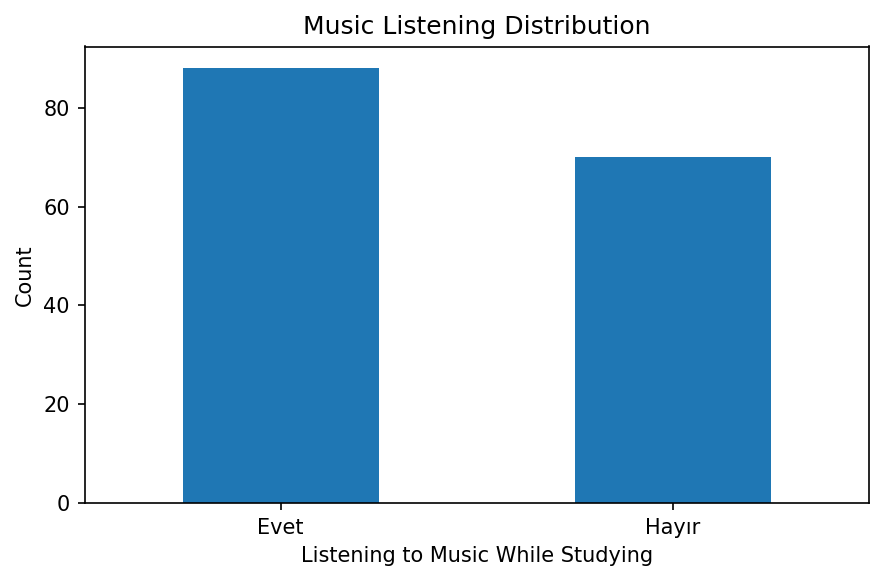

In [1]:
survey["music"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Music Listening Distribution")
plt.xlabel("Listening to Music While Studying")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Plot 2: Study Hours Distribution

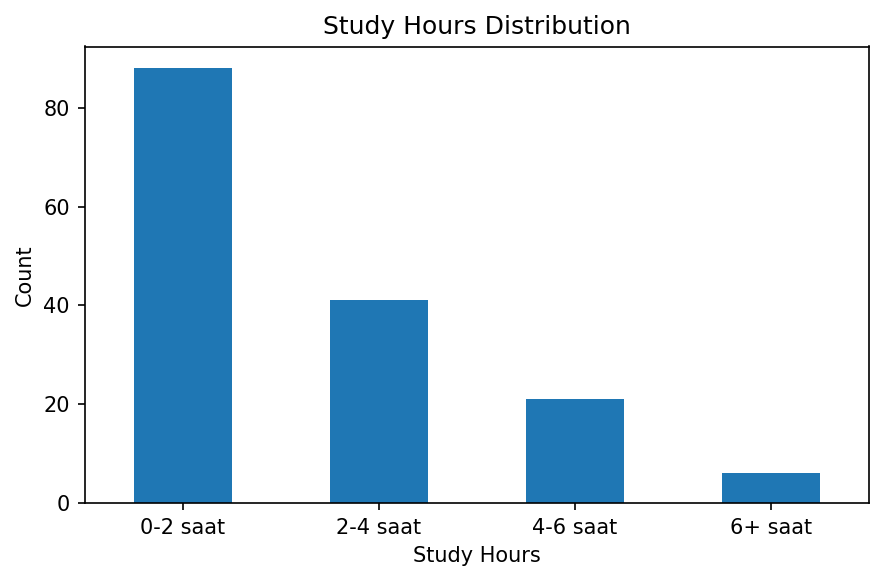

In [1]:
survey["study_hours"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Plot 3: Average Focus by Music

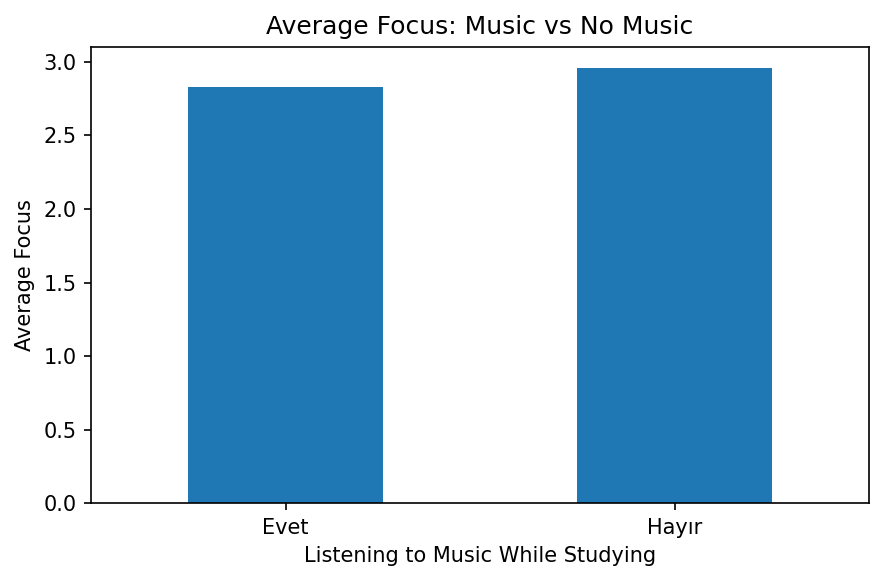

In [1]:
survey.groupby("music")["focus"].mean().plot(kind="bar", figsize=(6, 4))
plt.title("Average Focus: Music vs No Music")
plt.xlabel("Listening to Music While Studying")
plt.ylabel("Average Focus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Plot 4: Average Focus by Study Hours

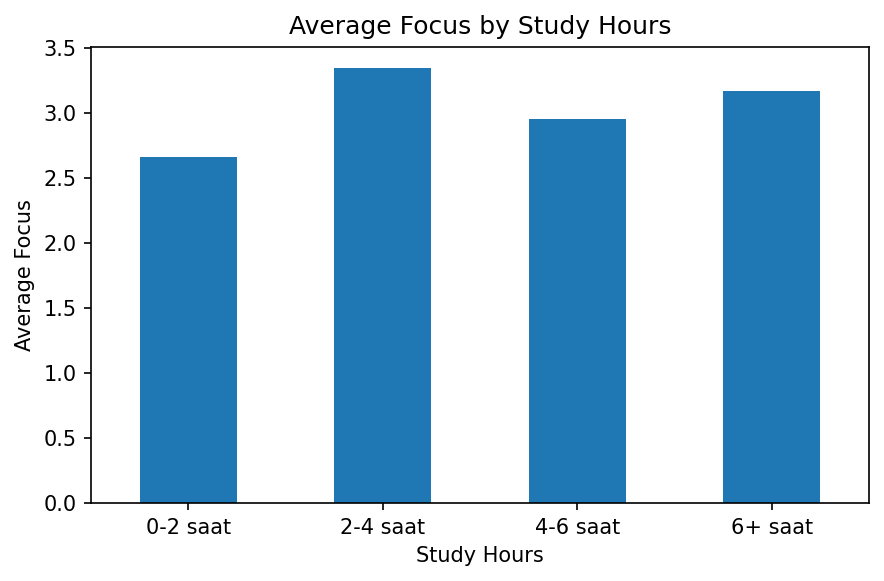

In [1]:
survey.groupby("study_hours", observed=False)["focus"].mean().plot(kind="bar", figsize=(6, 4))
plt.title("Average Focus by Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Average Focus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Plot 5: Average Focus by Genre

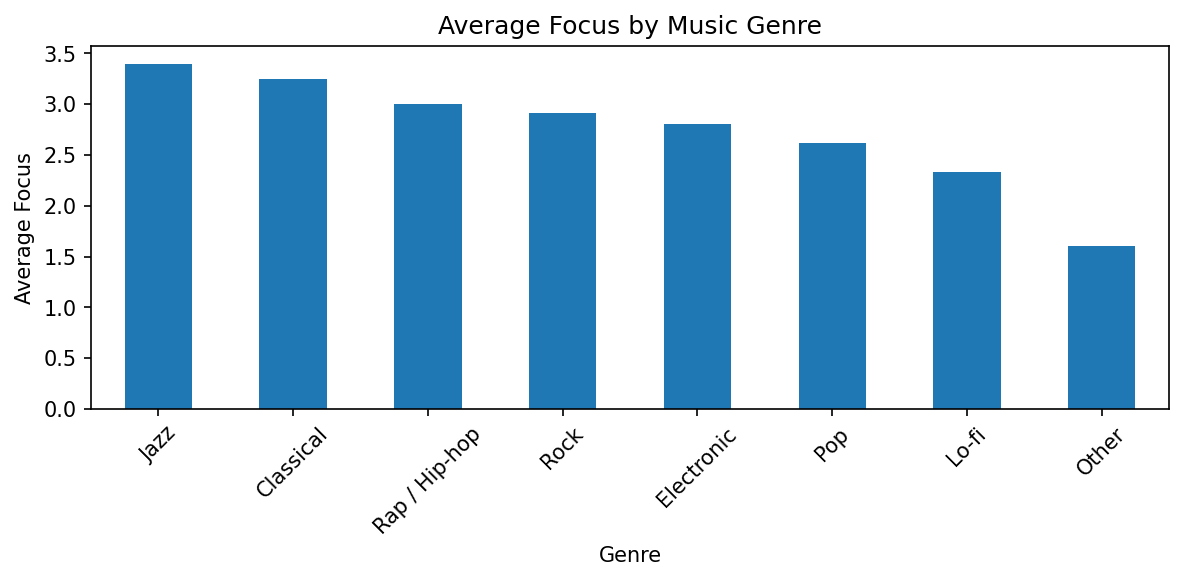

In [1]:
survey_music.groupby("genre")["focus"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(8, 4))
plt.title("Average Focus by Music Genre")
plt.xlabel("Genre")
plt.ylabel("Average Focus")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Plot 6: Spotify Audio Features by Genre

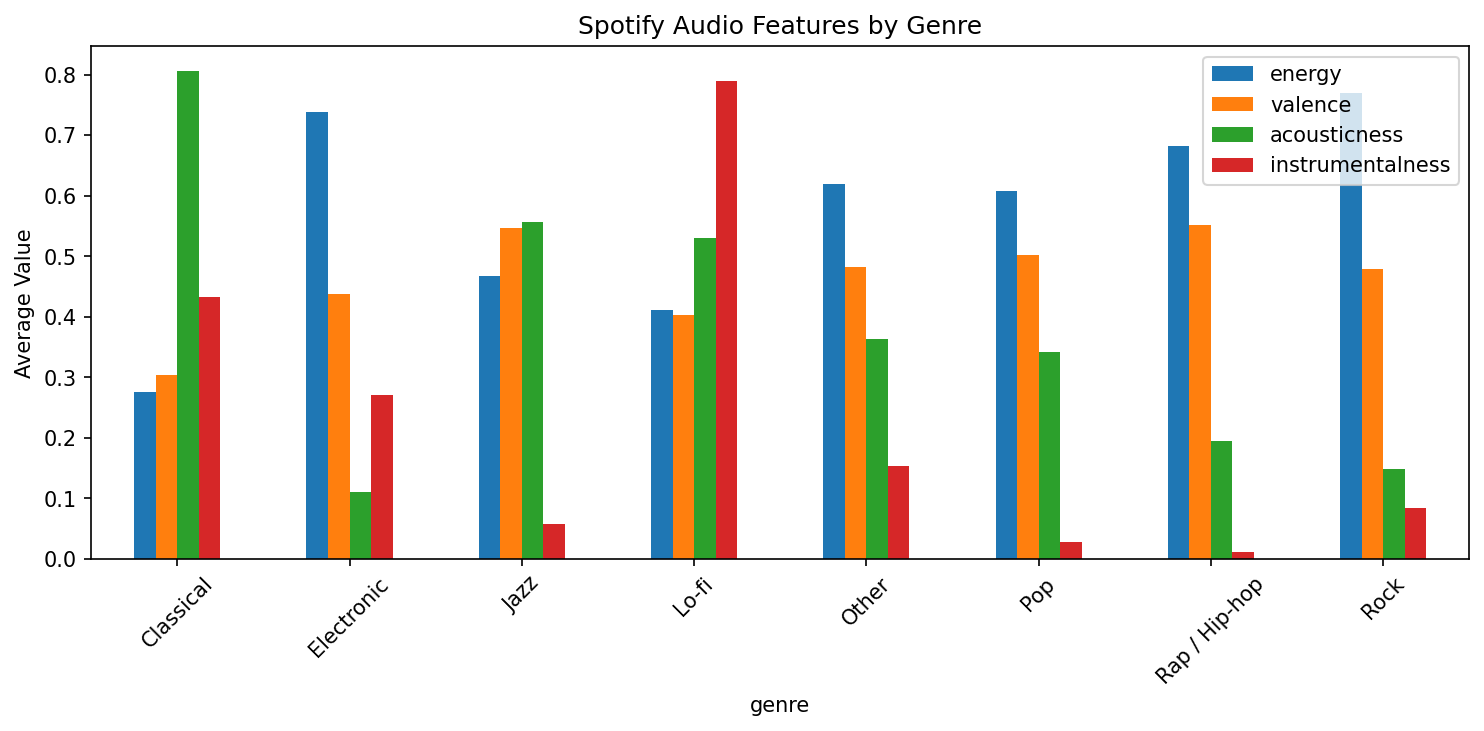

In [1]:
spotify_grouped.set_index("genre")[["energy", "valence", "acousticness", "instrumentalness"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Spotify Audio Features by Genre")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Plot 7: Average Tempo by Genre

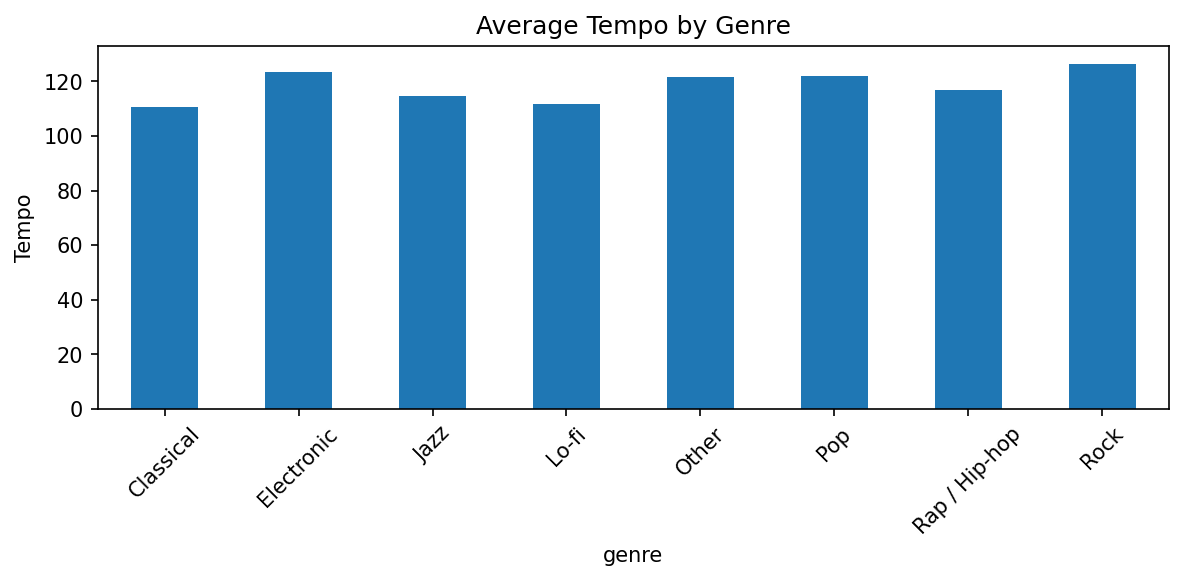

In [1]:
spotify_grouped.set_index("genre")["tempo"].plot(kind="bar", figsize=(8, 4))
plt.title("Average Tempo by Genre")
plt.ylabel("Tempo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Hypothesis Tests

### H1: Music vs No Music on Focus

In [1]:
focus_music = survey.loc[survey["music"] == "Evet", "focus"]
focus_no_music = survey.loc[survey["music"] == "Hayır", "focus"]

t_stat_1, p_value_1 = ttest_ind(focus_music, focus_no_music, nan_policy="omit")

print("H1: Music vs No Music on Focus")
print("t-statistic:", round(t_stat_1, 4))
print("p-value:", round(p_value_1, 6))
if p_value_1 < 0.05:
    print("Result: Reject H0 -> Significant difference in focus.")
else:
    print("Result: Fail to reject H0 -> No significant difference in focus.")


H1: Music vs No Music on Focus
t-statistic: -0.7048
p-value: 0.481955
Result: Fail to reject H0 -> No significant difference in focus.


### H2: Genre vs Focus

In [1]:
genre_groups = []
for g in survey_music["genre"].dropna().unique():
    vals = survey_music.loc[survey_music["genre"] == g, "focus"].dropna()
    if len(vals) >= 2:
        genre_groups.append(vals)

f_stat_2, p_value_2 = f_oneway(*genre_groups)

print("H2: Genre vs Focus")
print("F-statistic:", round(f_stat_2, 4))
print("p-value:", round(p_value_2, 6))
if p_value_2 < 0.05:
    print("Result: Reject H0 -> Focus differs significantly by genre.")
else:
    print("Result: Fail to reject H0 -> No significant genre effect on focus.")


H2: Genre vs Focus
F-statistic: 1.8404
p-value: 0.090814
Result: Fail to reject H0 -> No significant genre effect on focus.


### H3: Study Duration vs Focus

In [1]:
hours_groups = []
for h in study_order:
    vals = survey.loc[survey["study_hours"] == h, "focus"].dropna()
    if len(vals) >= 2:
        hours_groups.append(vals)

f_stat_3, p_value_3 = f_oneway(*hours_groups)

print("H3: Study Duration vs Focus")
print("F-statistic:", round(f_stat_3, 4))
print("p-value:", round(p_value_3, 6))
if p_value_3 < 0.05:
    print("Result: Reject H0 -> Focus differs significantly across study-hour groups.")
else:
    print("Result: Fail to reject H0 -> No significant effect of study duration on focus.")


H3: Study Duration vs Focus
F-statistic: 3.7647
p-value: 0.012112
Result: Reject H0 -> Focus differs significantly across study-hour groups.


### H4: Spotify Audio Features vs Focus

In [1]:
print("H4: Spotify Audio Features vs Focus")
for feature in ["energy", "danceability", "tempo", "valence", "acousticness", "instrumentalness"]:
    temp_df = survey_music.dropna(subset=[feature, "focus"])
    r, p = pearsonr(temp_df[feature], temp_df["focus"])
    print(f"{feature}: r = {round(r,4)}, p-value = {round(p,6)}")


H4: Spotify Audio Features vs Focus
energy: r = -0.1065, p-value = 0.323569
danceability: r = -0.112, p-value = 0.298812
tempo: r = -0.1453, p-value = 0.176673
valence: r = -0.0782, p-value = 0.468798
acousticness: r = 0.1056, p-value = 0.327679
instrumentalness: r = -0.012, p-value = 0.911401


### H5: Music vs Study Duration

In [1]:
contingency = pd.crosstab(survey["music"], survey["study_hours"])
chi2_stat_5, p_value_5, dof_5, expected_5 = chi2_contingency(contingency)

print("H5: Music vs Study Duration")
print("Chi-square statistic:", round(chi2_stat_5, 4))
print("p-value:", round(p_value_5, 6))
if p_value_5 < 0.05:
    print("Result: Reject H0 -> Music listening and study duration are significantly related.")
else:
    print("Result: Fail to reject H0 -> No significant relationship between music listening and study duration.")
print("Contingency Table:")
print(contingency)


H5: Music vs Study Duration
Chi-square statistic: 2.1928
p-value: 0.533358
Result: Fail to reject H0 -> No significant relationship between music listening and study duration.
Contingency Table:
study_hours  0-2 saat  2-4 saat  4-6 saat  6+ saat
music                                             
Evet               45        24        14        4
Hayır              43        17         7        2
